# Previsão de Performance e Bem-estar de Alunos

**Autores:** [Nome 1, Nº aluno] | [Nome 2, Nº aluno] | [Nome 3, Nº aluno] | **Grupo:** [Nº grupo]  
**Unidade Curricular:** Fundamentos de Aprendizagem Automática — 2024/2025  
**Data:** Abril 2026

---

## Introdução

O bem-estar e o desempenho académico dos alunos são influenciados por um conjunto complexo de fatores comportamentais e de estilo de vida. Com o aumento das exigências académicas, o burnout estudantil tornou-se uma preocupação crescente em instituições de ensino superior.

Este projeto aplica técnicas de **aprendizagem automática supervisionada** a um dataset de 5000 registos de alunos, com o objetivo de desenvolver modelos preditivos capazes de identificar alunos em risco e prever o seu desempenho académico com base em variáveis como hábitos de sono, tempo de estudo, uso de ecrãs, prática de exercício e saúde mental.

---

## Problema e Objetivos

Definimos duas tarefas preditivas complementares:

| Tarefa | Tipo | Target | Objetivo |
|--------|------|--------|----------|
| Prever nível de Burnout | **Classificação** | Baixo / Médio / Alto | Identificar alunos em risco de esgotamento |
| Prever Exam Score | **Regressão** | Nota contínua (0–100) | Estimar o desempenho académico esperado |

**Stakeholders:** Instituições de ensino, psicólogos escolares e os próprios alunos beneficiam destas previsões para intervir preventivamente e personalizar estratégias de apoio.

---

## Dataset

- **Dimensão:** 5000 registos × 21 features
- **Fonte:** `student_records_missing.csv` (contém valores em falta intencionais)
- **Tipos de variáveis:**
  - 11 numéricas contínuas (horas de estudo, sono, ecrã, exercício, etc.)
  - 2 nominais (`gender`, `academic_level`)
  - 1 ordinal (`internet_quality`)
  - 2 binárias (`part_time_job`, `upcoming_deadline`)
  - 4 targets (`focus_index`, `burnout_level`, `productivity_score`, `exam_score`)
  - 1 identificador (`student_id`, removido)

---


## Métricas de Avaliação

| Tarefa | Métrica Primária | Métrica Secundária |
|--------|-----------------|-------------------|
| Classificação (Burnout) | **F1-macro** — robusto a desequilíbrio entre classes | **Accuracy** — referência global |
| Regressão (Exam Score) | **MAE** — interpretável na unidade da nota | **R²** — proporção de variância explicada |

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, train_test_split, KFold, StratifiedKFold
from sklearn.metrics import (mean_absolute_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

## 0. Carregar Dados e Preparar

Carregamos o dataset e definimos os tipos de cada feature:
- **Numéricas** (11): variáveis contínuas como horas de estudo, sono, ecrã — requerem imputação e escalonamento
- **Nominais** (2): `gender`, `academic_level` — sem ordem natural, codificadas com One-Hot (get_dummies)
- **Ordinal** (1): `internet_quality` — tem ordem (fraco < médio < bom), codificada com LabelEncoder
- **Binárias** (2): `part_time_job`, `upcoming_deadline` — já em formato 0/1

Removemos `student_id` (identificador sem valor preditivo) e todos os targets do espaço de features.

In [36]:
df = pd.read_csv('../Dados_Projeto/student_records_missing.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColunas do dataset:")
print(df.columns.tolist())

numeric_features = ['study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 
                     'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'mental_health_score', 'age']
nominal_features = ['gender', 'academic_level']
ordinal_features = ['internet_quality']
binary_features = ['part_time_job', 'upcoming_deadline']

all_targets = ['focus_index', 'burnout_level', 'productivity_score', 'exam_score']

X = df.drop(columns=all_targets + ['student_id'])

y_exam_score = df['exam_score']  # Regressão: prever a nota contínua
y_burnout_continuous = df['burnout_level']  # Será transformado em 3 classes

print(f"\nX shape: {X.shape}")
print(f"Features totais: {X.shape[1]}")
print(f"Exam Score (regressão): {y_exam_score.shape}")
print(f"Burnout Level (será classificação): {y_burnout_continuous.shape}")

Dataset shape: (5000, 21)

Colunas do dataset:
['student_id', 'age', 'gender', 'academic_level', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score']

X shape: (5000, 16)
Features totais: 16
Exam Score (regressão): (5000,)
Burnout Level (será classificação): (5000,)


## 0.1 Análise Exploratória dos Dados (EDA)

Antes de qualquer transformação, analisamos os dados originais para compreender:
- Distribuição de cada variável numérica
- Valores em falta por coluna
- Correlações entre features

In [37]:
print("=" * 55)
print("VALORES EM FALTA POR COLUNA")
print("=" * 55)

null_table = pd.DataFrame({
    'Nulos':    df.isnull().sum(),
    '% Nulos':  (df.isnull().mean() * 100).round(2)
}).sort_values('% Nulos', ascending=False)
null_table = null_table[null_table['Nulos'] > 0]

if len(null_table) == 0:
    print("Nenhum valor em falta encontrado.")
else:
    print(null_table.to_string())
    print(f"\nTotal de colunas com nulos: {len(null_table)}")
    print(f"Total de células em falta:  {df.isnull().sum().sum()} / {df.size} ({df.isnull().mean().mean()*100:.2f}%)")

total_null_pct = df.isnull().mean().mean() * 100
if total_null_pct < 5:
    print(f"  {total_null_pct:.1f}% de valores em falta → percentagem baixa, imputação adequada.")
elif total_null_pct < 15:
    print(f"  {total_null_pct:.1f}% de valores em falta → percentagem moderada, requer imputação cuidadosa.")
else:
    print(f"  {total_null_pct:.1f}% de valores em falta → percentagem elevada, analisar padrão de missings.")

VALORES EM FALTA POR COLUNA
                     Nulos  % Nulos
mental_health_score    750     15.0
caffeine_intake_mg     500     10.0
screen_time_hours      400      8.0
social_media_hours     250      5.0
gender                 150      3.0
academic_level         100      2.0

Total de colunas com nulos: 6
Total de células em falta:  2150 / 105000 (2.05%)
  2.0% de valores em falta → percentagem baixa, imputação adequada.


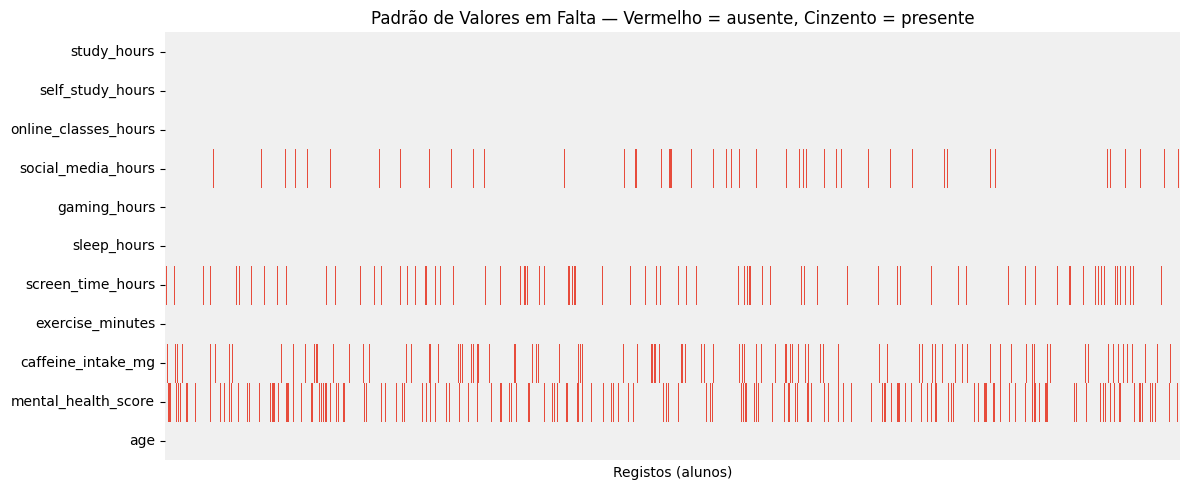

In [38]:
numeric_cols_eda = ['study_hours','self_study_hours','online_classes_hours',
                    'social_media_hours','gaming_hours','sleep_hours',
                    'screen_time_hours','exercise_minutes','caffeine_intake_mg',
                    'mental_health_score','age']

missing_matrix = df[numeric_cols_eda].isnull().astype(int)

plt.figure(figsize=(12, 5))
sns.heatmap(missing_matrix.T, cmap=['#f0f0f0','#e74c3c'],
            cbar=False, yticklabels=numeric_cols_eda,
            xticklabels=False)
plt.title('Padrão de Valores em Falta — Vermelho = ausente, Cinzento = presente')
plt.xlabel('Registos (alunos)')
plt.tight_layout()
plt.show()

Se os valores ausentes se distribuem **aleatoriamente** ao longo dos registos (sem padrão vertical visível), estamos perante um cenário **MAR (Missing At Random)**. Neste caso, a imputação por **KNN Imputer** é adequada: cada valor em falta é estimado com base nos *k* vizinhos mais próximos no espaço de features.

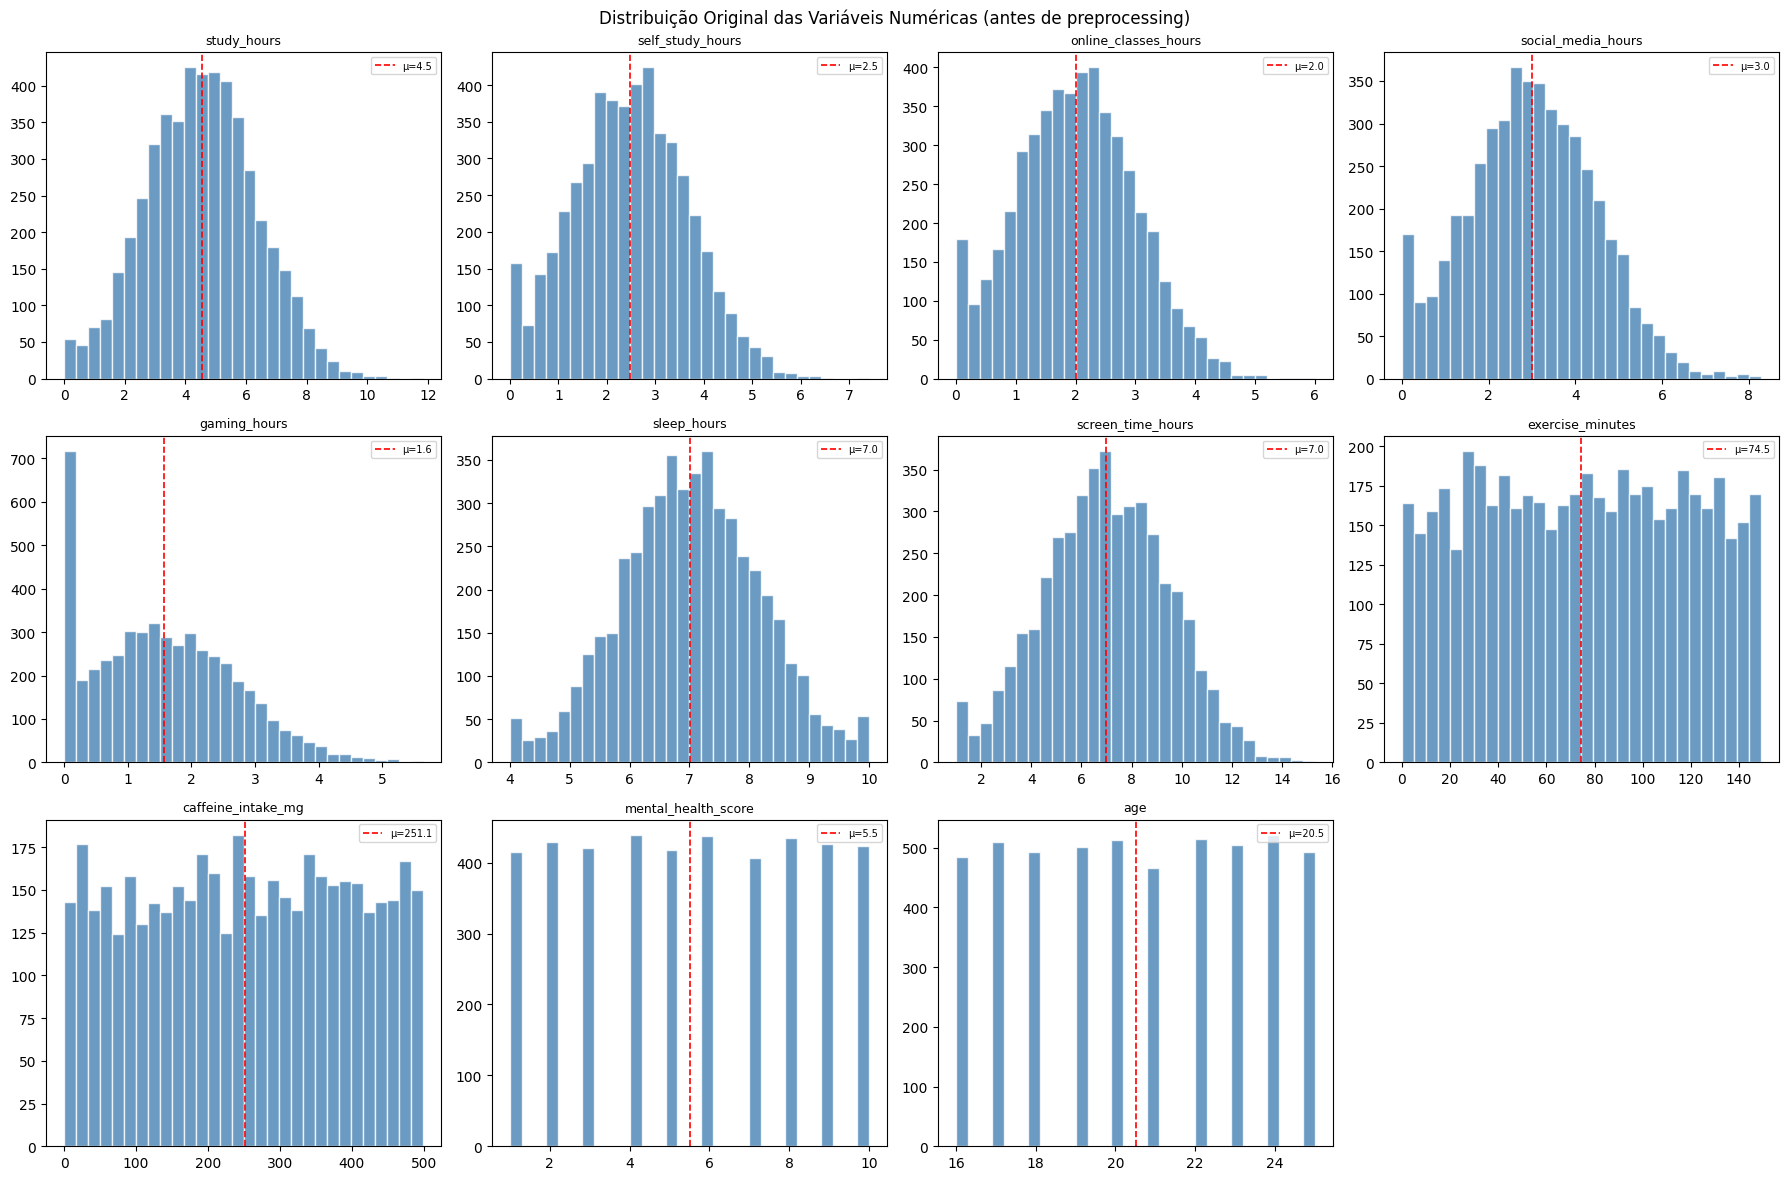

In [39]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_eda):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--',
                    linewidth=1.2, label=f'μ={mean_val:.1f}')
    axes[i].legend(fontsize=7)

for j in range(len(numeric_cols_eda), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição Original das Variáveis Numéricas (antes de preprocessing)', fontsize=12)
plt.tight_layout()
plt.show()

Histogramas com **cauda longa** ou **picos extremos** indicam potenciais outliers, tratados na secção seguinte com o método IQR. A **linha vermelha** representa a média de cada variável. Distribuições muito assimétricas podem reduzir a eficácia do StandardScaler.

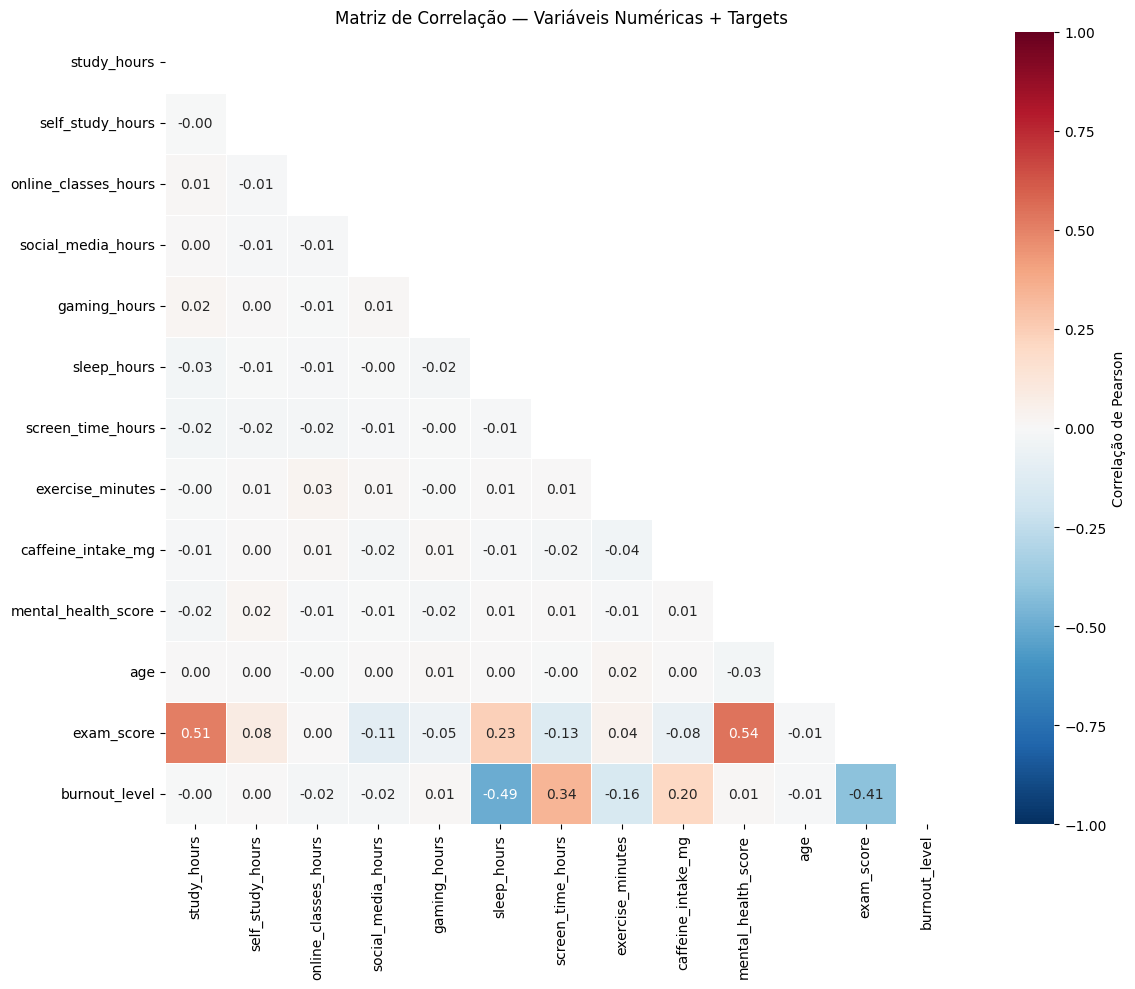


Top features correlacionadas com exam_score:
  mental_health_score            0.544
  study_hours                    0.513
  sleep_hours                    0.235
  screen_time_hours              0.133
  social_media_hours             0.109

Top features correlacionadas com burnout_level:
  sleep_hours                    0.493
  screen_time_hours              0.343
  caffeine_intake_mg             0.204
  exercise_minutes               0.157
  social_media_hours             0.021


In [40]:
corr_cols = numeric_cols_eda + ['exam_score', 'burnout_level']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlação de Pearson'})
plt.title('Matriz de Correlação — Variáveis Numéricas + Targets')
plt.tight_layout()
plt.show()

print("\nTop features correlacionadas com exam_score:")
exam_corr = corr_matrix['exam_score'].drop(['exam_score','burnout_level']).abs().sort_values(ascending=False)
for feat, val in exam_corr.head(5).items():
    print(f"  {feat:30} {val:.3f}")

print("\nTop features correlacionadas com burnout_level:")
burn_corr = corr_matrix['burnout_level'].drop(['exam_score','burnout_level']).abs().sort_values(ascending=False)
for feat, val in burn_corr.head(5).items():
    print(f"  {feat:30} {val:.3f}")


Correlações **acima de 0.5** ou **abaixo de −0.5** indicam relações fortes entre features e targets — são as mais relevantes para os modelos. Correlações próximas de 0 sugerem features pouco discriminativas. Correlações altas *entre features* (multicolinearidade) podem afetar modelos lineares, mas não os baseados em árvores de decisão.


Burnout Level - Quantis para 3 classes:
Quantil 1/3: 39.00
Quantil 2/3: 51.67

Distribuição das classes de Burnout:
0    1667
1    1666
2    1667
Name: count, dtype: int64
Percentagens: 0    33.3
1    33.3
2    33.3
Name: count, dtype: float64


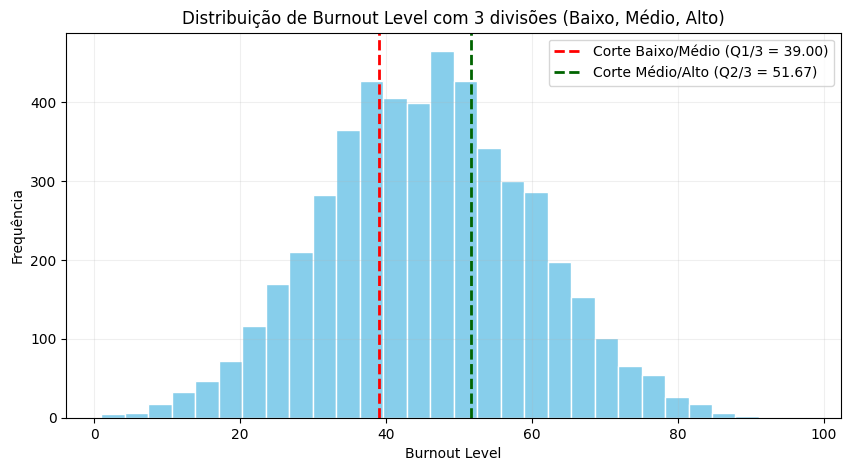

In [41]:
quantiles = y_burnout_continuous.quantile([1/3, 2/3])
q1 = quantiles.iloc[0]
q2 = quantiles.iloc[1]

print(f"\nBurnout Level - Quantis para 3 classes:")
print(f"Quantil 1/3: {q1:.2f}")
print(f"Quantil 2/3: {q2:.2f}")

y_burnout_class = pd.cut(
    y_burnout_continuous,
    bins=[y_burnout_continuous.min() - 1, q1, q2, y_burnout_continuous.max() + 1],
    labels=['Baixo', 'Médio', 'Alto'],
    include_lowest=True
)

y_burnout_class_encoded = pd.Categorical(y_burnout_class).codes

print(f"\nDistribuição das classes de Burnout:")
print(pd.Series(y_burnout_class_encoded).value_counts().sort_index())
print(f"Percentagens: {(pd.Series(y_burnout_class_encoded).value_counts().sort_index() / len(y_burnout_class_encoded) * 100).round(1)}")

plt.figure(figsize=(10, 5))
plt.hist(y_burnout_continuous, bins=30, color='skyblue', edgecolor='white')
plt.axvline(q1, color='red', linestyle='--', linewidth=2, label=f'Corte Baixo/Médio (Q1/3 = {q1:.2f})')
plt.axvline(q2, color='darkgreen', linestyle='--', linewidth=2, label=f'Corte Médio/Alto (Q2/3 = {q2:.2f})')
plt.title('Distribuição de Burnout Level com 3 divisões (Baixo, Médio, Alto)')
plt.xlabel('Burnout Level')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 0.6 Deteção e Remoção de Outliers

Detetamos outliers nas variáveis numéricas usando o método **IQR (Interquartile Range)**:

- **Limite inferior:** Q1 − 1.5 × IQR
- **Limite superior:** Q3 + 1.5 × IQR

1. Na distribuição normal, 1.5×IQR corresponde a ~2.7σ
2. Isto significa outliers além de 2.7 desvios-padrão
3. Esperado: ~0.7% de dados removidos (pontos extremos genuínos)

- Se removemos > 5%: considerar distribuição com cauda longa
- Se removemos < 0.1%: dataset muito limpo

Valores fora destes limites são considerados outliers e removidos do dataset antes da divisão treino/teste.
Mostramos boxplots antes e depois da remoção para visualizar o impacto.

BOXPLOTS ANTES DA REMOÇÃO DE OUTLIERS


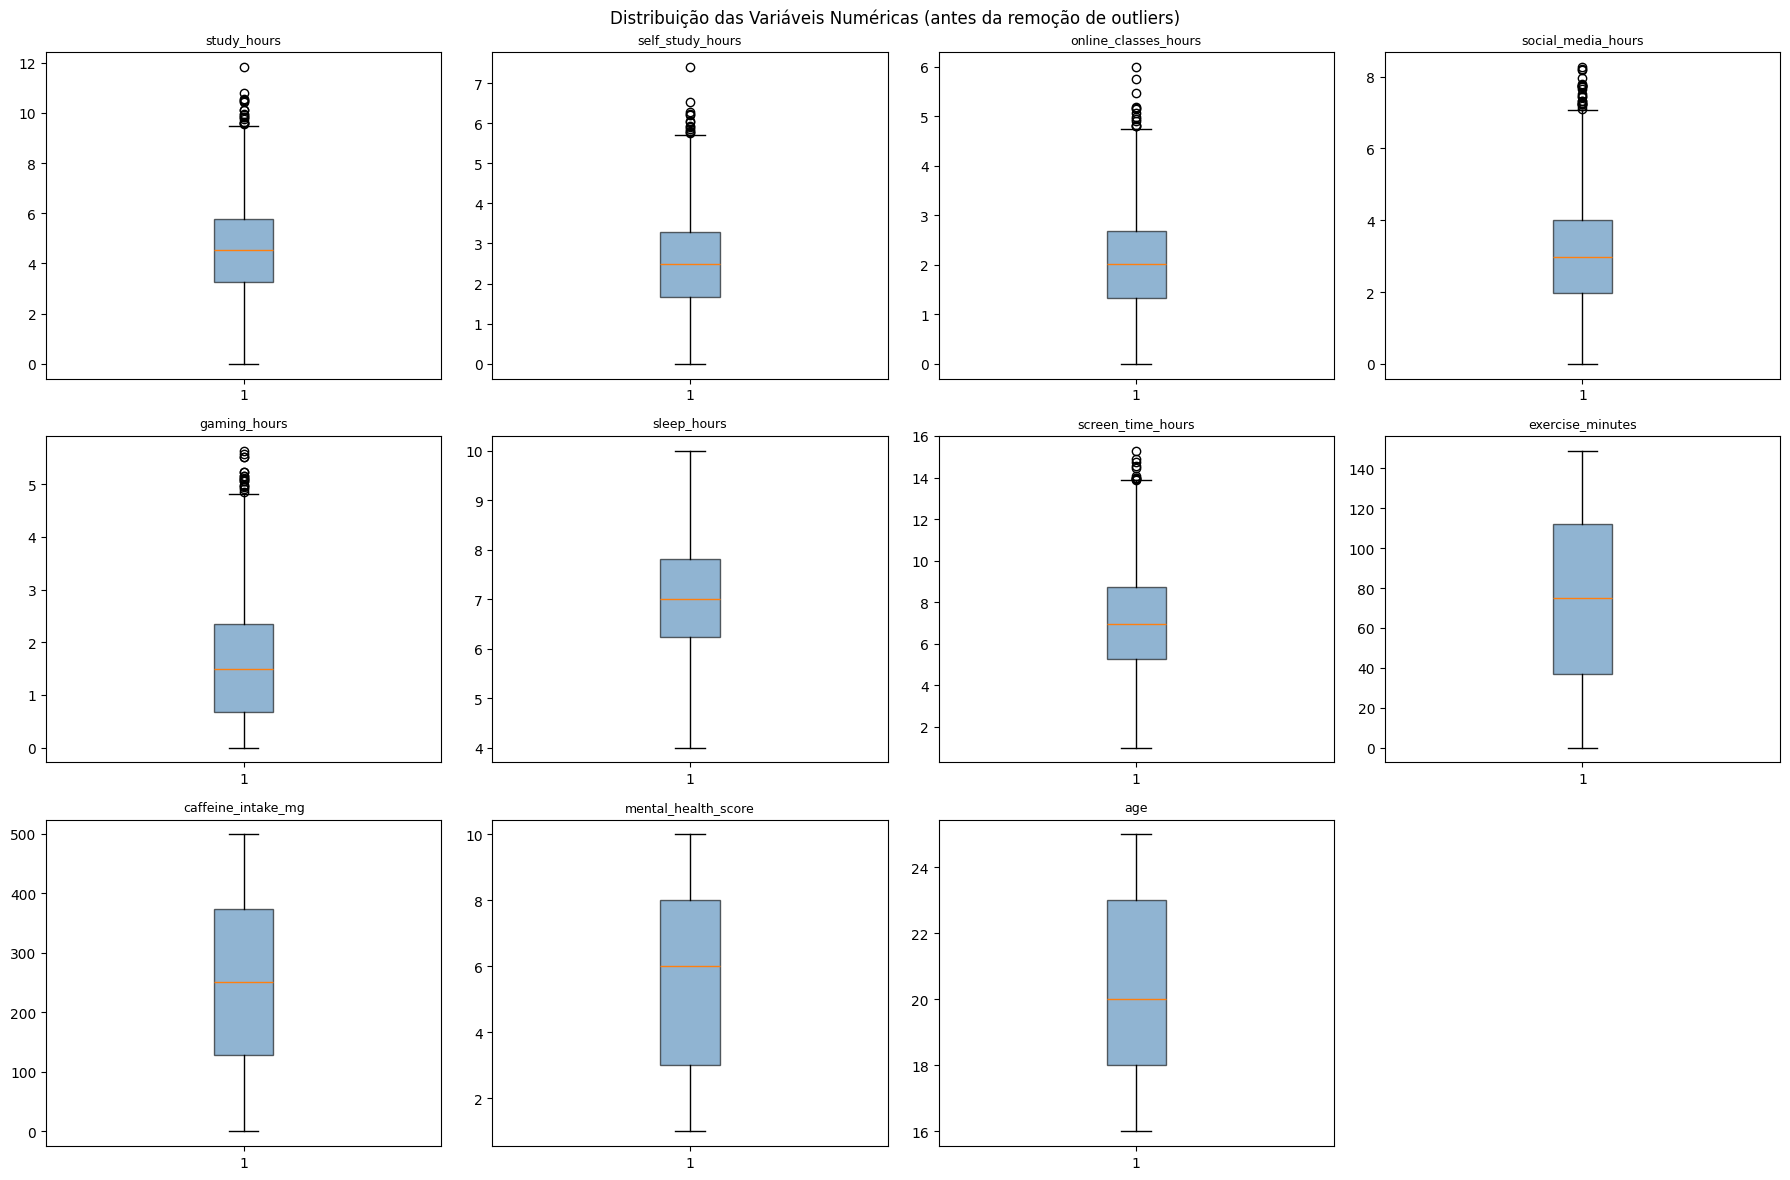


OUTLIERS DETETADOS POR FEATURE (Método IQR)
  study_hours                    | [-0.51, 9.52] | 17 outliers
  self_study_hours               | [-0.79, 5.74] | 13 outliers
  online_classes_hours           | [-0.73, 4.74] | 13 outliers
  social_media_hours             | [-1.08, 7.08] | 22 outliers
  gaming_hours                   | [-1.83, 4.84] | 18 outliers
  screen_time_hours              | [0.12, 13.88] | 11 outliers

Total de linhas com pelo menos 1 outlier: 93 / 5000 (1.9%)

Dataset após remoção: 4907 registos (removidos 93)
Distribuição de classes (Burnout) após limpeza:
Baixo    1636
Médio    1636
Alto     1635
Name: count, dtype: int64

BOXPLOTS APÓS REMOÇÃO DE OUTLIERS


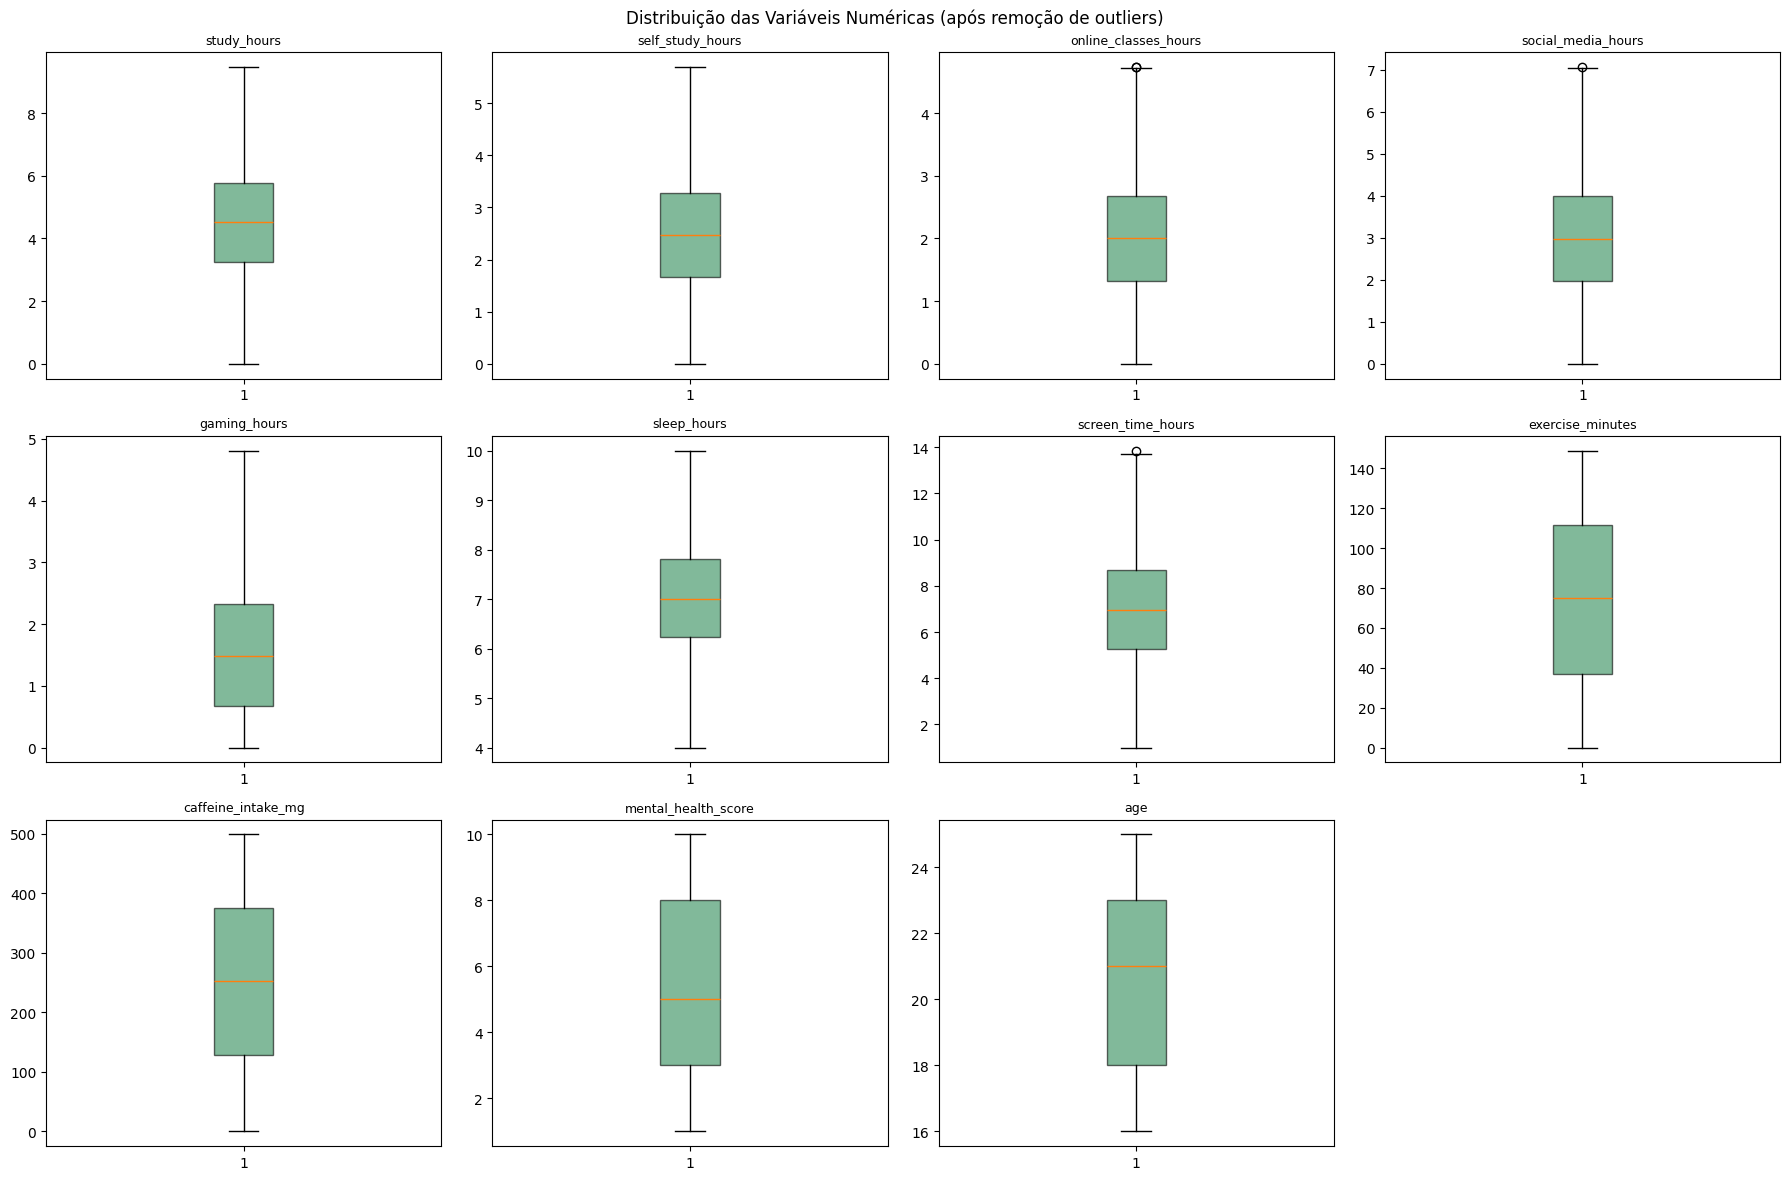

In [54]:
numeric_cols = ['study_hours', 'self_study_hours', 'online_classes_hours',
                'social_media_hours', 'gaming_hours', 'sleep_hours',
                'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg',
                'mental_health_score', 'age']

print("=" * 70)
print("BOXPLOTS ANTES DA REMOÇÃO DE OUTLIERS")
print("=" * 70)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribuição das Variáveis Numéricas (antes da remoção de outliers)', fontsize=12)
plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("OUTLIERS DETETADOS POR FEATURE (Método IQR)")
print("=" * 70)

outlier_mask = pd.Series([False] * len(df), index=df.index)
outlier_summary = []

for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    col_outliers = (df[col] < lower) | (df[col] > upper)
    n_outliers = col_outliers.sum()
    outlier_mask = outlier_mask | col_outliers
    outlier_summary.append({
        'Feature': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower': lower, 'Upper': upper, 'Outliers': n_outliers
    })
    if n_outliers > 0:
        print(f"  {col:30} | [{lower:.2f}, {upper:.2f}] | {n_outliers} outliers")

total_outliers = outlier_mask.sum()
print(f"\nTotal de linhas com pelo menos 1 outlier: {total_outliers} / {len(df)} ({total_outliers/len(df)*100:.1f}%)")


df_clean = df[~outlier_mask].copy()

X = df_clean.drop(columns=all_targets + ['student_id'])
y_exam_score = df_clean['exam_score']
y_burnout_continuous = df_clean['burnout_level']

quantiles_clean = y_burnout_continuous.quantile([1/3, 2/3])
q1_c, q2_c = quantiles_clean.iloc[0], quantiles_clean.iloc[1]
y_burnout_class = pd.cut(y_burnout_continuous,
    bins=[y_burnout_continuous.min()-1, q1_c, q2_c, y_burnout_continuous.max()+1],
    labels=['Baixo', 'Médio', 'Alto'], include_lowest=True)
y_burnout_class_encoded = pd.Categorical(y_burnout_class).codes

print(f"\nDataset após remoção: {df_clean.shape[0]} registos (removidos {len(df) - df_clean.shape[0]})")
print(f"Distribuição de classes (Burnout) após limpeza:")
print(pd.Series(y_burnout_class_encoded).value_counts().sort_index()
      .rename({0:'Baixo', 1:'Médio', 2:'Alto'}))


print("\n" + "=" * 70)
print("BOXPLOTS APÓS REMOÇÃO DE OUTLIERS")
print("=" * 70)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='seagreen', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribuição das Variáveis Numéricas (após remoção de outliers)', fontsize=12)
plt.tight_layout()
plt.show()

---

# PRÉ-PROCESSAMENTO

## 0.5 Análise de Valores em Falta e Estratégias de Imputação

O dataset `student_records_missing.csv` contém valores em falta intencionais para simular dados reais.

**Estratégia:** Imputação por **KNN Imputer (k=5)** para todas as variáveis numéricas.
- O KNN Imputer encontra os 5 registos mais semelhantes (vizinhos) e usa os seus valores para imputar o valor em falta
- É preferível à mediana porque **captura as correlações entre features** — o valor imputado é coerente com o perfil completo do aluno
- A imputação é ajustada apenas no **Learning Set** (`fit_transform`) e aplicada ao Test Set (`transform`), evitando data leakage

## 1. Divisão Learning Set e Test Set

Dividimos os dados em **80% Learning Set** e **20% Test Set** com `random_state=42` para reprodutibilidade.

- O **Learning Set** é usado exclusivamente para treino, validação cruzada e seleção de modelos
- O **Test Set** é guardado e só usado na avaliação final — simula dados novos nunca vistos pelo modelo
- Para classificação usamos `stratify=y` para garantir que a proporção de classes (Baixo/Médio/Alto) é preservada em ambos os conjuntos

In [43]:
X_exam_learning, X_exam_test, y_exam_learning, y_exam_test = train_test_split(
    X, y_exam_score, test_size=0.2, random_state=42
)

X_burnout_learning, X_burnout_test, y_burnout_learning, y_burnout_test = train_test_split(
    X, y_burnout_class_encoded, test_size=0.2, random_state=42, stratify=y_burnout_class_encoded
)

print(f"Learning set shape: {X_exam_learning.shape}")
print(f"Test set shape: {X_exam_test.shape}")

print(f"\nDistribuição de classes no Learning Set:")
print(pd.Series(y_burnout_learning).value_counts().sort_index())

Learning set shape: (3925, 16)
Test set shape: (982, 16)

Distribuição de classes no Learning Set:
0    1308
1    1309
2    1308
Name: count, dtype: int64


## 2. Construir o Pipeline de Pré-processamento

Construímos um pipeline que aplica transformações diferentes consoante o tipo de variável:

| Tipo | Variáveis | Transformação | Justificação |
|------|-----------|--------------|--------------|
| Nominal | `gender`, `academic_level` | **One-Hot (get_dummies)** | Sem ordem natural — One-Hot evita introduzir relações ordinais falsas |
| Ordinal | `internet_quality` | **LabelEncoder** | Tem ordem (fraco < médio < bom) — encoding ordinal preserva essa relação |
| Numérica + Binária | 11 + 2 variáveis | **KNN Imputer (k=5) + StandardScaler** | KNN imputa com base nos 5 vizinhos mais semelhantes, capturando correlações entre features; StandardScaler é apropriado porque CV detecta overfitting → normalização adequada |

**Porquê KNN Imputer em vez da mediana?**
As features comportamentais deste dataset têm correlações entre si (ex: alunos com poucas horas de sono tendem a ter maior consumo de cafeína). O KNN Imputer aproveita essas relações para imputar valores mais realistas, ao contrário da mediana que imputa o mesmo valor para todos os alunos independentemente do seu perfil.

O pipeline é ajustado **apenas no Learning Set** (`fit_transform`) e aplicado ao Test Set (`transform`) para evitar data leakage.

In [44]:
X = pd.get_dummies(X, columns=nominal_features, drop_first=False)
X_learning = pd.get_dummies(X_exam_learning, columns=nominal_features, drop_first=False)
X_test = pd.get_dummies(X_exam_test, columns=nominal_features, drop_first=False)
X_learning_clf = pd.get_dummies(X_burnout_learning, columns=nominal_features, drop_first=False)
X_test_clf = pd.get_dummies(X_burnout_test, columns=nominal_features, drop_first=False)

label_encoders = {}
for col in ordinal_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    X_learning[col] = le.transform(X_learning[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    X_learning_clf[col] = le.transform(X_learning_clf[col].astype(str))
    X_test_clf[col] = le.transform(X_test_clf[col].astype(str))
    label_encoders[col] = le

num_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

columns_to_process = numeric_features + binary_features
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, columns_to_process)
], remainder='passthrough')

print(f"✓ Pipeline construído com KNNImputer(k=5) para: {columns_to_process}")

✓ Pipeline construído com KNNImputer(k=5) para: ['study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'mental_health_score', 'age', 'part_time_job', 'upcoming_deadline']


In [45]:
print(f"  Shape: {X_learning.shape}")
print(f"  Colunas: {list(X_learning.columns)}\n")

X_learning_processed = preprocessor.fit_transform(X_learning)

processed_feature_names = preprocessor.get_feature_names_out()
X_learning_processed_df = pd.DataFrame(
    X_learning_processed,
    columns=processed_feature_names,
    index=X_learning.index
)

print(f"\nPrimeiras 10 linhas do dataset processado:")
print(X_learning_processed_df.head(10))
print(f"\nShape após tratamento: {X_learning_processed_df.shape}")
print(f"Total de features finais: {X_learning_processed_df.shape[1]}")
print(f"\nColunas finais: {list(X_learning_processed_df.columns)}\n")

csv_path = './X_learning_preprocessed.csv'
X_learning_processed_df.to_csv(csv_path)
print(f"✓ Ficheiro salvo em: {csv_path}")
print(f"✓ Dados: {X_learning_processed_df.shape[0]} linhas × {X_learning_processed_df.shape[1]} colunas")

  Shape: (3925, 20)
  Colunas: ['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score', 'gender_Female', 'gender_Male', 'gender_Other', 'academic_level_High School', 'academic_level_Postgraduate', 'academic_level_Undergraduate']


Primeiras 10 linhas do dataset processado:
     num__study_hours num__self_study_hours num__online_classes_hours  \
3473         0.593207             -1.004782                  2.161495   
851         -1.689129              0.430013                   1.70028   
2630         0.087872             -1.013374                  1.956511   
4176         0.820885             -0.850134                  -1.34374   
3435         0.171169             -1.778025                 -0.523802   
4706         -1.21156               0.52452                 -0.206076   
2207    

---

# PARTE 1: CLASSIFICAÇÃO — Prever Nível de Burnout

O target `burnout_level` é dividido em 3 classes equilibradas pelos quantis 1/3 e 2/3:
**Baixo** (0) | **Médio** (1) | **Alto** (2)

In [46]:
X_burnout_learning_processed = preprocessor.fit_transform(X_learning_clf)
X_burnout_test_processed     = preprocessor.transform(X_test_clf)

X_burnout_learning_df = pd.DataFrame(
    X_burnout_learning_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_learning_clf.index
)
X_burnout_test_df = pd.DataFrame(
    X_burnout_test_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_test_clf.index
)
print(f"Learning set (classificação): {X_burnout_learning_df.shape}")
print(f"Test set     (classificação): {X_burnout_test_df.shape}")

Learning set (classificação): (3925, 20)
Test set     (classificação): (982, 20)


## 1. Baseline: Decision Tree com Validação Cruzada

A **Árvore de Decisão** é o modelo interpretável de referência para classificação.
Testamos diferentes valores de `max_depth` via **5-fold Stratified CV** no Learning Set.

- **Métrica primária:** F1-macro — robusto a desequilíbrio entre classes
- **Métrica secundária:** Accuracy — referência global

In [47]:
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

depths_clf = [2, 3, 4, 5, 6, 7, 8, 10, None]
cv_rows = []

for depth in depths_clf:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_validate(
        Pipeline([('model', model)]),
        X_burnout_learning_df, y_burnout_learning,
        cv=skfold,
        scoring={'accuracy': 'accuracy', 'f1': 'f1_macro'},
        return_train_score=True
    )
    cv_rows.append({
        'max_depth':      str(depth),
        'train_accuracy': scores['train_accuracy'].mean(),
        'val_accuracy':   scores['test_accuracy'].mean(),
        'val_f1_macro':   scores['test_f1'].mean(),
        'std_f1':         scores['test_f1'].std(),
    })

cv_df_clf = pd.DataFrame(cv_rows)
print("Validação Cruzada — Decision Tree (5-fold):")
print(cv_df_clf.to_string(index=False))

best_idx      = cv_df_clf['val_f1_macro'].idxmax()
best_depth_str = cv_df_clf.loc[best_idx, 'max_depth']
best_depth_clf = None if best_depth_str == 'None' else int(best_depth_str)
best_f1_cv     = cv_df_clf.loc[best_idx, 'val_f1_macro']
best_acc_cv    = cv_df_clf.loc[best_idx, 'val_accuracy']
best_std_cv    = cv_df_clf.loc[best_idx, 'std_f1']

print(f"\n✓ Melhor max_depth: {best_depth_clf}")
print(f"  Val F1-macro: {best_f1_cv:.4f} ± {best_std_cv:.4f}")
print(f"  Val Accuracy: {best_acc_cv:.4f}")

if best_f1_cv >= 0.75:
    f1_label = "BOM"
    f1_msg   = "O modelo distingue bem as 3 classes de burnout."
elif best_f1_cv >= 0.60:
    f1_label = "MODERADO"
    f1_msg   = "O modelo distingue razoavelmente as classes, com alguma confusão nos casos intermédios."
else:
    f1_label = "FRACO"
    f1_msg   = "O modelo tem dificuldade em distinguir as classes."

print(f"  F1-macro = {best_f1_cv:.4f} → {f1_label}")
print(f"  {f1_msg}")
print(f"  (Referência: um modelo aleatório com 3 classes equilibradas teria F1 ≈ 0.33)")

train_f1_best = cv_df_clf.loc[best_idx, 'train_accuracy']
gap = train_f1_best - best_acc_cv
if gap > 0.10:
    print(f"\n  Atenção: diferença treino-validação = {gap:.4f} → indício de overfitting.")
else:
    print(f"\n  Diferença treino-validação = {gap:.4f} → sem overfitting significativo.")

if best_std_cv < 0.02:
    print(f"  Desvio padrão F1 = {best_std_cv:.4f} → modelo estável entre folds.")
else:
    print(f"  Desvio padrão F1 = {best_std_cv:.4f} → alguma variabilidade entre folds.")

Validação Cruzada — Decision Tree (5-fold):
max_depth  train_accuracy  val_accuracy  val_f1_macro   std_f1
        2        0.587834      0.580637      0.587307 0.007732
        3        0.600255      0.593631      0.563044 0.027260
        4        0.676624      0.654268      0.656390 0.021530
        5        0.695732      0.661146      0.661010 0.019993
        6        0.745287      0.669809      0.669280 0.014794
        7        0.788089      0.656051      0.658366 0.011022
        8        0.836433      0.647134      0.649077 0.016484
       10        0.925478      0.628790      0.630911 0.020054
     None        1.000000      0.611210      0.612320 0.014882

✓ Melhor max_depth: 6
  Val F1-macro: 0.6693 ± 0.0148
  Val Accuracy: 0.6698
  F1-macro = 0.6693 → MODERADO
  O modelo distingue razoavelmente as classes, com alguma confusão nos casos intermédios.
  (Referência: um modelo aleatório com 3 classes equilibradas teria F1 ≈ 0.33)

  Diferença treino-validação = 0.0755 → sem ove

## 2. Avaliação Final no Test Set — Classificação

Treinamos o melhor modelo no Learning Set completo e avaliamos no Test Set (nunca visto durante a seleção).

RESULTADOS NO TEST SET — Decision Tree (Burnout)
  F1-macro  (primária):   0.6728
  Accuracy  (secundária): 0.6762
  Precision (macro):      0.6711
  Recall    (macro):      0.6760
  F1-macro = 0.6728 → MODERADO: classificação razoável, com erros principalmente na classe 'Médio'.
  Accuracy = 0.6762 → em 67.6% dos casos o modelo previu corretamente o nível de burnout.
  Precision = 0.6711 → quando o modelo prevê uma classe, acerta em média 67.1% das vezes.
  Recall = 0.6760 → o modelo deteta em média 67.6% dos casos de cada classe.

  CV vs Test Set: diferença de -0.0035 → resultados consistentes, sem overfitting.


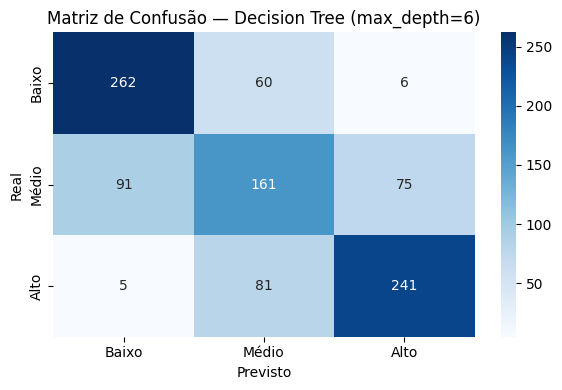


Relatório de Classificação:
              precision    recall  f1-score   support

       Baixo       0.73      0.80      0.76       328
       Médio       0.53      0.49      0.51       327
        Alto       0.75      0.74      0.74       327

    accuracy                           0.68       982
   macro avg       0.67      0.68      0.67       982
weighted avg       0.67      0.68      0.67       982



In [48]:
dt_final = DecisionTreeClassifier(max_depth=best_depth_clf, random_state=42)
dt_final.fit(X_burnout_learning_df, y_burnout_learning)
y_burnout_pred = dt_final.predict(X_burnout_test_df)

acc  = accuracy_score(y_burnout_test, y_burnout_pred)
f1   = f1_score(y_burnout_test, y_burnout_pred, average='macro', zero_division=0)
prec = precision_score(y_burnout_test, y_burnout_pred, average='macro', zero_division=0)
rec  = recall_score(y_burnout_test, y_burnout_pred, average='macro', zero_division=0)

print("=" * 60)
print("RESULTADOS NO TEST SET — Decision Tree (Burnout)")
print("=" * 60)
print(f"  F1-macro  (primária):   {f1:.4f}")
print(f"  Accuracy  (secundária): {acc:.4f}")
print(f"  Precision (macro):      {prec:.4f}")
print(f"  Recall    (macro):      {rec:.4f}")

if f1 >= 0.75:
    print(f"  F1-macro = {f1:.4f} → BOM: o modelo classifica bem as 3 classes de burnout.")
elif f1 >= 0.60:
    print(f"  F1-macro = {f1:.4f} → MODERADO: classificação razoável, com erros principalmente na classe 'Médio'.")
else:
    print(f"  F1-macro = {f1:.4f} → FRACO: o modelo tem dificuldade em separar as classes.")

print(f"  Accuracy = {acc:.4f} → em {acc*100:.1f}% dos casos o modelo previu corretamente o nível de burnout.")
print(f"  Precision = {prec:.4f} → quando o modelo prevê uma classe, acerta em média {prec*100:.1f}% das vezes.")
print(f"  Recall = {rec:.4f} → o modelo deteta em média {rec*100:.1f}% dos casos de cada classe.")

gap_cv_test = best_f1_cv - f1
if abs(gap_cv_test) < 0.03:
    print(f"\n  CV vs Test Set: diferença de {gap_cv_test:.4f} → resultados consistentes, sem overfitting.")
elif gap_cv_test > 0.05:
    print(f"\n  CV vs Test Set: diferença de {gap_cv_test:.4f} → o modelo generaliza ligeiramente pior em dados novos.")

cm = confusion_matrix(y_burnout_test, y_burnout_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baixo','Médio','Alto'],
            yticklabels=['Baixo','Médio','Alto'])
plt.title(f'Matriz de Confusão — Decision Tree (max_depth={best_depth_clf})')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_burnout_test, y_burnout_pred,
                            target_names=['Baixo','Médio','Alto'], zero_division=0))

---

# PARTE 2: REGRESSÃO — Prever Exam Score

O target `exam_score` é uma variável contínua (0–100) que representa a nota do aluno.

In [49]:
X_reg_learning_processed = preprocessor.fit_transform(X_learning)
X_reg_test_processed     = preprocessor.transform(X_test)

X_reg_learning_df = pd.DataFrame(
    X_reg_learning_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_learning.index
)
X_reg_test_df = pd.DataFrame(
    X_reg_test_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)
print(f"Learning set (regressão): {X_reg_learning_df.shape}")
print(f"Test set     (regressão): {X_reg_test_df.shape}")

Learning set (regressão): (3925, 20)
Test set     (regressão): (982, 20)


## 3. Baseline: Linear Regression com Validação Cruzada

A **Regressão Linear** é o modelo interpretável de referência para regressão.
Avaliada com **5-fold CV** no Learning Set.

- **Métrica primária:** MAE — erro médio em pontos, interpretável na unidade da nota
- **Métrica secundária:** R² — proporção de variância explicada pelo modelo

In [50]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

lr = LinearRegression()
scores_reg = cross_validate(
    Pipeline([('model', lr)]),
    X_reg_learning_df, y_exam_learning,
    cv=kfold,
    scoring=['neg_mean_absolute_error', 'r2'],
    return_train_score=True
)

val_mae = -scores_reg['test_neg_mean_absolute_error']
val_r2  =  scores_reg['test_r2']

print("Validação Cruzada — Linear Regression (5-fold):")
print(f"  MAE (primária):   {val_mae.mean():.4f} ± {val_mae.std():.4f}")
print(f"  R²  (secundária): {val_r2.mean():.4f} ± {val_r2.std():.4f}")

mae_cv = val_mae.mean()
r2_cv  = val_r2.mean()

print(f"  MAE = {mae_cv:.4f} pontos")
print(f"  → Em média, o modelo erra {mae_cv:.1f} pontos na previsão da nota (escala 0-100).")

if mae_cv < 5:
    print(f"  → Erro reduzido: previsão bastante precisa.")
elif mae_cv < 10:
    print(f"  → Erro moderado: previsão útil mas com margem de incerteza.")
else:
    print(f"  → Erro elevado: o modelo tem dificuldade em prever a nota com precisão.")

print(f"\n  R² = {r2_cv:.4f}")
print(f"  → O modelo explica {r2_cv*100:.1f}% da variância nas notas dos alunos.")
if r2_cv >= 0.70:
    print(f"  → BOM: a maioria da variação nas notas é capturada pelas features.")
elif r2_cv >= 0.50:
    print(f"  → MODERADO: o modelo captura parte relevante da variação, mas há fatores não explicados.")
else:
    print(f"  → FRACO: o modelo explica pouca variação — as features podem não ser suficientes.")

print(f"\n  Estabilidade MAE entre folds: ± {val_mae.std():.4f} → ", end='')
print("estável." if val_mae.std() < 1.0 else "alguma variabilidade entre folds.")

Validação Cruzada — Linear Regression (5-fold):
  MAE (primária):   5.4281 ± 0.1678
  R²  (secundária): 0.6733 ± 0.0143
  MAE = 5.4281 pontos
  → Em média, o modelo erra 5.4 pontos na previsão da nota (escala 0-100).
  → Erro moderado: previsão útil mas com margem de incerteza.

  R² = 0.6733
  → O modelo explica 67.3% da variância nas notas dos alunos.
  → MODERADO: o modelo captura parte relevante da variação, mas há fatores não explicados.

  Estabilidade MAE entre folds: ± 0.1678 → estável.


## 4. Avaliação Final no Test Set — Regressão

Treinamos a Regressão Linear no Learning Set completo e avaliamos no Test Set.

RESULTADOS NO TEST SET — Linear Regression (Exam Score)
  MAE  (primária):   5.4572
  R²   (secundária): 0.6596
  RMSE:              6.9361
  MAE = 5.4572 pontos
  → O modelo erra em média 5.5 pontos ao prever a nota de um aluno.
  → Numa escala de 0 a 100, isso representa um erro de 5.5%.

  R² = 0.6596
  → O modelo explica 66.0% da variância nas notas.
  → Os restantes 34.0% devem-se a fatores não capturados (talento, sorte, etc.).

  RMSE = 6.9361 pontos
  → RMSE > MAE (6.94 > 5.46) indica a presença de alguns erros grandes (outliers de previsão).

  CV vs Test Set: diferença de -0.0291 → resultados consistentes.


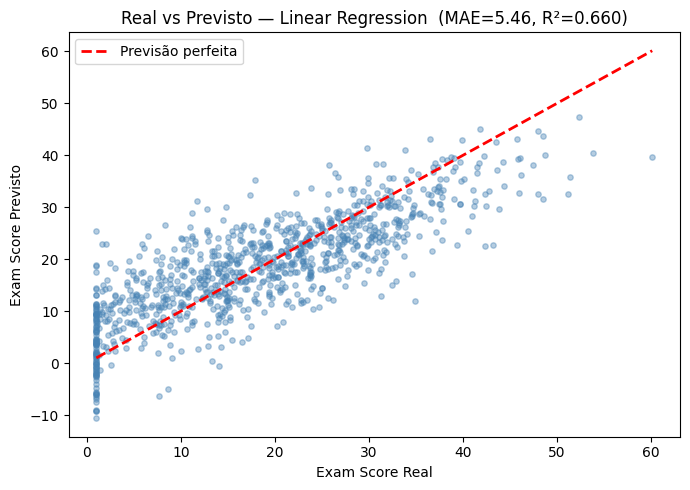

In [51]:
lr_final = LinearRegression()
lr_final.fit(X_reg_learning_df, y_exam_learning)
y_exam_pred = lr_final.predict(X_reg_test_df)

mae  = mean_absolute_error(y_exam_test, y_exam_pred)
r2   = r2_score(y_exam_test, y_exam_pred)
rmse = np.sqrt(np.mean((np.array(y_exam_test) - y_exam_pred)**2))

print("=" * 60)
print("RESULTADOS NO TEST SET — Linear Regression (Exam Score)")
print("=" * 60)
print(f"  MAE  (primária):   {mae:.4f}")
print(f"  R²   (secundária): {r2:.4f}")
print(f"  RMSE:              {rmse:.4f}")

print(f"  MAE = {mae:.4f} pontos")
print(f"  → O modelo erra em média {mae:.1f} pontos ao prever a nota de um aluno.")
print(f"  → Numa escala de 0 a 100, isso representa um erro de {mae:.1f}%.")

print(f"\n  R² = {r2:.4f}")
print(f"  → O modelo explica {r2*100:.1f}% da variância nas notas.")
print(f"  → Os restantes {(1-r2)*100:.1f}% devem-se a fatores não capturados (talento, sorte, etc.).")

print(f"\n  RMSE = {rmse:.4f} pontos")
print(f"  → RMSE > MAE ({rmse:.2f} > {mae:.2f}) indica a presença de alguns erros grandes (outliers de previsão).")

gap_cv_test = val_mae.mean() - mae
if abs(gap_cv_test) < 0.5:
    print(f"\n  CV vs Test Set: diferença de {gap_cv_test:.4f} → resultados consistentes.")
elif gap_cv_test < 0:
    print(f"\n  CV vs Test Set: o modelo performou melhor no Test Set do que na CV — resultado robusto.")
else:
    print(f"\n  CV vs Test Set: diferença de {gap_cv_test:.4f} → ligeira perda de performance em dados novos.")

plt.figure(figsize=(7, 5))
plt.scatter(y_exam_test, y_exam_pred, alpha=0.4, color='steelblue', s=15)
plt.plot([np.array(y_exam_test).min(), np.array(y_exam_test).max()],
         [np.array(y_exam_test).min(), np.array(y_exam_test).max()],
         'r--', linewidth=2, label='Previsão perfeita')
plt.xlabel('Exam Score Real')
plt.ylabel('Exam Score Previsto')
plt.title(f'Real vs Previsto — Linear Regression  (MAE={mae:.2f}, R²={r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

## Generalização — CV vs Test Set

Comparamos os resultados obtidos na **validação cruzada** (Learning Set) com os do **Test Set** para avaliar se o modelo generaliza bem para dados novos.

Um **gap pequeno** (< 0.03) indica boa generalização. Um gap grande indica overfitting.

In [52]:
print("=" * 70)
print("GENERALIZAÇÃO — CV vs Test Set")
print("=" * 70)
print(f"\n{'':35} {'CV (Learning Set)':>18} {'Test Set':>10} {'Gap':>8}")
print("─" * 70)
print(f"  {'CLASSIFICAÇÃO — F1-macro':33} {best_f1_cv:>18.4f} {f1:>10.4f} {f1-best_f1_cv:>+8.4f}")
print(f"  {'CLASSIFICAÇÃO — Accuracy':33} {best_acc_cv:>18.4f} {acc:>10.4f} {acc-best_acc_cv:>+8.4f}")
print(f"  {'REGRESSÃO — MAE':33} {val_mae.mean():>18.4f} {mae:>10.4f} {mae-val_mae.mean():>+8.4f}")
print(f"  {'REGRESSÃO — R²':33} {val_r2.mean():>18.4f} {r2:>10.4f} {r2-val_r2.mean():>+8.4f}")
print("─" * 70)

clf_gap = abs(f1 - best_f1_cv)
reg_gap = abs(mae - val_mae.mean())

if clf_gap < 0.03:
    print(f"  Classificação: gap F1 = {f1-best_f1_cv:+.4f} → boa generalização, sem overfitting.")
elif clf_gap < 0.07:
    print(f"  Classificação: gap F1 = {f1-best_f1_cv:+.4f} → generalização razoável.")
else:
    print(f"  Classificação: gap F1 = {f1-best_f1_cv:+.4f} → overfitting — modelo ajustado em demasia ao Learning Set.")

if reg_gap < 1.0:
    print(f"  Regressão: gap MAE = {mae-val_mae.mean():+.4f} → boa generalização.")
elif reg_gap < 2.0:
    print(f"  Regressão: gap MAE = {mae-val_mae.mean():+.4f} → generalização razoável.")
else:
    print(f"  Regressão: gap MAE = {mae-val_mae.mean():+.4f} → overfitting.")

GENERALIZAÇÃO — CV vs Test Set

                                     CV (Learning Set)   Test Set      Gap
──────────────────────────────────────────────────────────────────────
  CLASSIFICAÇÃO — F1-macro                      0.6693     0.6728  +0.0035
  CLASSIFICAÇÃO — Accuracy                      0.6698     0.6762  +0.0064
  REGRESSÃO — MAE                               5.4281     5.4572  +0.0291
  REGRESSÃO — R²                                0.6733     0.6596  -0.0137
──────────────────────────────────────────────────────────────────────
  Classificação: gap F1 = +0.0035 → boa generalização, sem overfitting.
  Regressão: gap MAE = +0.0291 → boa generalização.


---

## Resumo Final — Fase I

In [53]:
print("=" * 65)
print("RESUMO — MODELOS BASELINE (Fase I)")
print("=" * 65)
print(f"\n1. CLASSIFICAÇÃO — Burnout Level")
print(f"   Modelo:    Decision Tree (max_depth={best_depth_clf})")
print(f"   F1-macro:  {f1:.4f}  (primária)   → {'BOM' if f1>=0.75 else 'MODERADO' if f1>=0.60 else 'FRACO'}")
print(f"   Accuracy:  {acc:.4f}  (secundária) → acerta em {acc*100:.1f}% dos casos")
print(f"\n2. REGRESSÃO — Exam Score")
print(f"   Modelo:    Linear Regression")
print(f"   MAE:       {mae:.4f}  (primária)   → erro médio de {mae:.1f} pontos (escala 0-100)")
print(f"   R²:        {r2:.4f}  (secundária) → explica {r2*100:.1f}% da variância nas notas")
print("=" * 65)
print("\nEstes resultados estabelecem o BASELINE da Fase I.")
print("Na Fase II serão testados modelos mais complexos para tentar superar estes valores.")

RESUMO — MODELOS BASELINE (Fase I)

1. CLASSIFICAÇÃO — Burnout Level
   Modelo:    Decision Tree (max_depth=6)
   F1-macro:  0.6728  (primária)   → MODERADO
   Accuracy:  0.6762  (secundária) → acerta em 67.6% dos casos

2. REGRESSÃO — Exam Score
   Modelo:    Linear Regression
   MAE:       5.4572  (primária)   → erro médio de 5.5 pontos (escala 0-100)
   R²:        0.6596  (secundária) → explica 66.0% da variância nas notas

Estes resultados estabelecem o BASELINE da Fase I.
Na Fase II serão testados modelos mais complexos para tentar superar estes valores.
